Данный код загружает датасет insurance.csv и визуализирует распределение четырёх ключевых признаков: возраста, индекса массы тела (BMI), количества детей и медицинских расходов. Для каждого признака построена отдельная диаграмма с настройками цвета, подписей осей и заголовков. Визуализация выполнена с использованием библиотек pandas в единой сетке графиков 2×2.

/tmp/ipykernel_24931/4127777276.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend()
/tmp/ipykernel_24931/4127777276.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 1].legend()
/tmp/ipykernel_24931/4127777276.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, 1].legend()


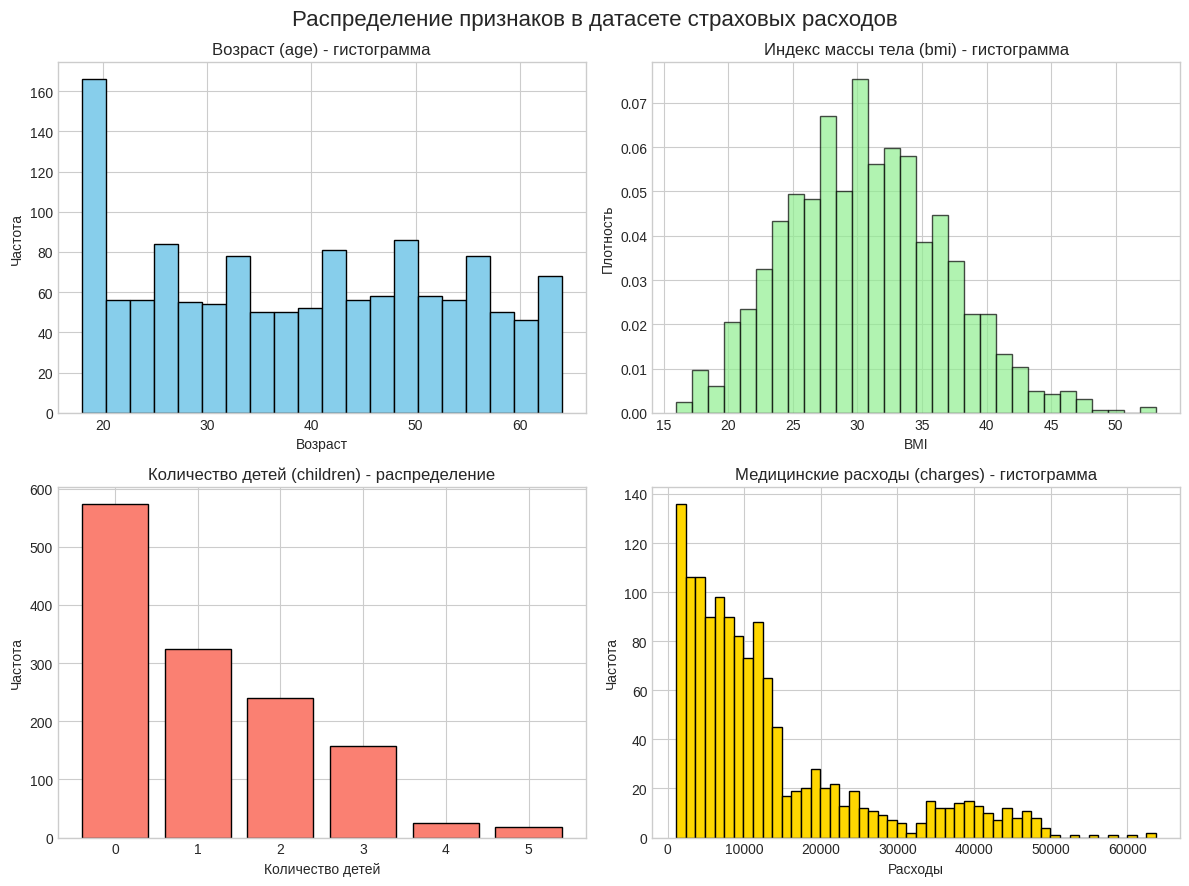

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider


# Загрузка данных
df = pd.read_csv('insurance.csv')

# Настройка стиля и размера графиков
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Распределение признаков в датасете страховых расходов', fontsize=16)

# 1. Возраст (age) - гистограмма
axes[0, 0].hist(df['age'], bins=20, edgecolor='black', color='skyblue')
axes[0, 0].set_title('Возраст (age) - гистограмма')
axes[0, 0].set_xlabel('Возраст')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].legend()

# 2. ИМТ (bmi) - гистограмма с KDE
axes[0, 1].hist(df['bmi'], bins=30, edgecolor='black', color='lightgreen', density=True, alpha=0.7)
axes[0, 1].set_title('Индекс массы тела (bmi) - гистограмма')
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('Плотность')
axes[0, 1].legend()

# 3. Количество детей (children) - столбчатая диаграмма
children_counts = df['children'].value_counts().sort_index()
axes[1, 0].bar(children_counts.index, children_counts.values, color='salmon', edgecolor='black')
axes[1, 0].set_title('Количество детей (children) - распределение')
axes[1, 0].set_xlabel('Количество детей')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].set_xticks(children_counts.index)



# 7. Расходы (charges) - гистограмма с логарифмической шкалой (из-за выбросов)
axes[1, 1].hist(df['charges'], bins=50, edgecolor='black', color='gold')
axes[1, 1].set_title('Медицинские расходы (charges) - гистограмма')
axes[1, 1].set_xlabel('Расходы')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].legend()



plt.tight_layout()
plt.show()

Данный код визуализирует влияние трёх факторов (возраста, индекса массы тела и количества детей) на медицинские расходы с разделением по статусу курения. Для этого категориальные признаки sex, smoker и region преобразуются в числовые значения с помощью Label Encoding, чтобы их можно было использовать в корреляционном анализе. На трёх точечных диаграммах (scatter plot) зелёным цветом показаны некурящие пациенты, красным — курящие, что позволяет наглядно сравнить распределение расходов в этих группах. Результаты отображаются в единой сетке 1×3.

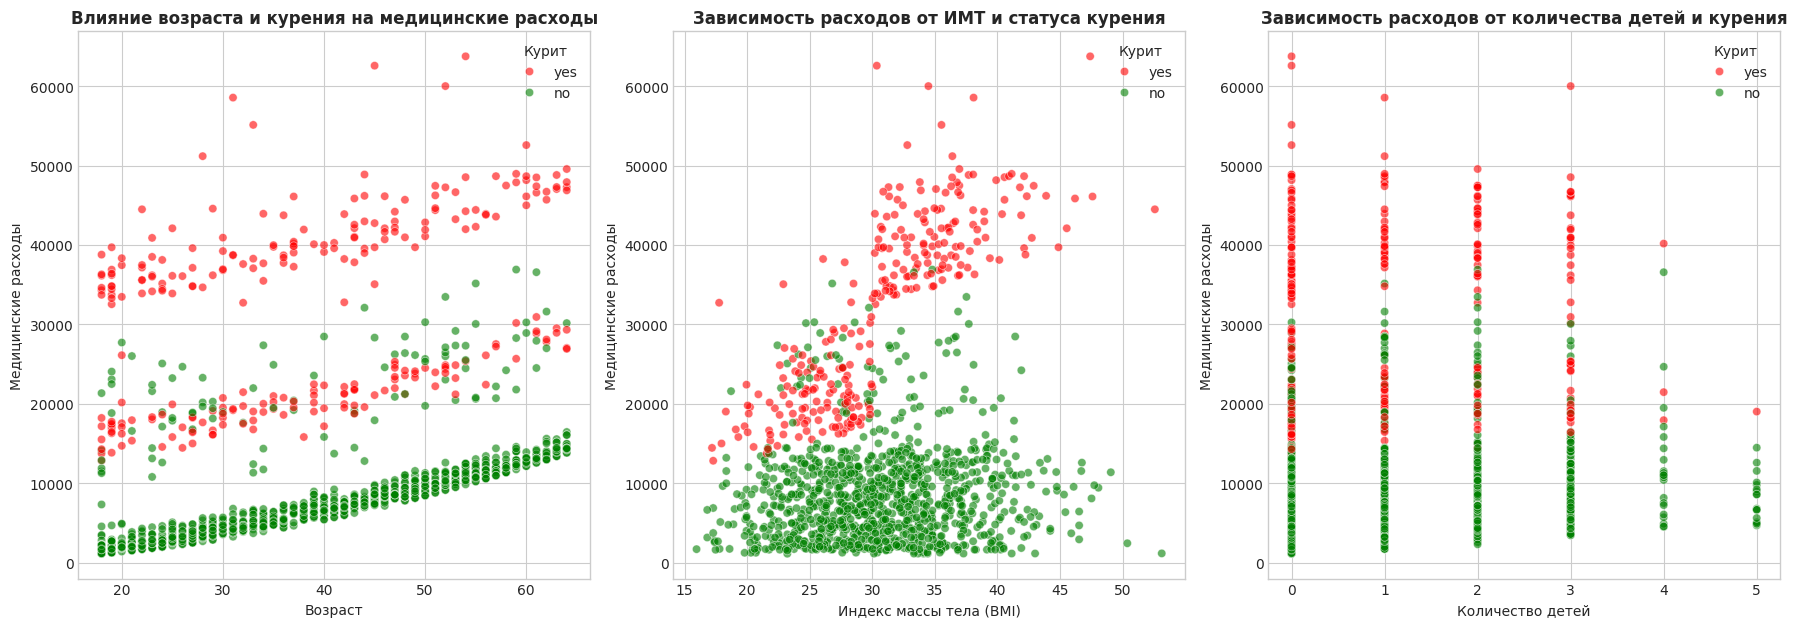

In [ ]:
# Преобразование категориальных признаков для корреляции
df_encoded = df.copy()
df_encoded['sex'] = df_encoded['sex'].map({'female': 0, 'male': 1})
df_encoded['smoker'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})
df_encoded['region'] = df_encoded['region'].astype('category').cat.codes

# Настройка стиля seaborn
sns.set_style('whitegrid')
sns.set_palette('husl')

# Создание фигуры с тремя графиками
fig = plt.figure(figsize=(18, 12))

# -------------------------------------------------------------------
# 1. Визуализация: Влияние возраста и статуса курения на расходы
# -------------------------------------------------------------------
ax1 = plt.subplot(2, 3, 1)
scatter = sns.scatterplot(
    data=df,
    x='age',
    y='charges',
    hue='smoker',
    alpha=0.6,
    palette={'no': 'green', 'yes': 'red'},
    ax=ax1
)
ax1.set_title('Влияние возраста и курения на медицинские расходы', fontsize=12, fontweight='bold')
ax1.set_xlabel('Возраст')
ax1.set_ylabel('Медицинские расходы')
ax1.legend(title='Курит')



# -------------------------------------------------------------------
# 2. Визуализация: Зависимость расходов от ИМТ с разбивкой по курению
# -------------------------------------------------------------------
ax2 = plt.subplot(2, 3, 2)
sns.scatterplot(
    data=df,
    x='bmi',
    y='charges',
    hue='smoker',
    alpha=0.6,
    palette={'no': 'green', 'yes': 'red'},
    ax=ax2
)
ax2.set_title('Зависимость расходов от ИМТ и статуса курения', fontsize=12, fontweight='bold')
ax2.set_xlabel('Индекс массы тела (BMI)')
ax2.set_ylabel('Медицинские расходы')
ax2.legend(title='Курит')


# -------------------------------------------------------------------
# 3. Визуализация: Зависимость расходов от количества детей
# -------------------------------------------------------------------
ax3 = plt.subplot(2, 3, 3)
sns.scatterplot(
    data=df,
    x='children',
    y='charges',
    hue='smoker',
    alpha=0.6,
    palette={'no': 'green', 'yes': 'red'},
    ax=ax3
)
ax3.set_title('Зависимость расходов от количества детей и курения', fontsize=12, fontweight='bold')
ax3.set_xlabel('Количество детей')
ax3.set_ylabel('Медицинские расходы')
ax3.legend(title='Курит')



plt.tight_layout()
plt.show()

Данный код реализует интерактивную визуализацию двух признаков датасета. На левом графике отображается зависимость медицинских расходов от возраста, на правом — зависимость расходов от индекса массы тела (BMI), при этом цвет точек кодирует статус курения (зелёный — некурящие, красный — курящие). Слайдер в нижней части окна позволяет динамически фильтровать данные по минимальному возрасту, но colaboratory не позволяет это сделать.

/tmp/ipykernel_24931/111208097.py:26: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  fig.legend(['Некурящие', 'Курящие'], loc='upper right',


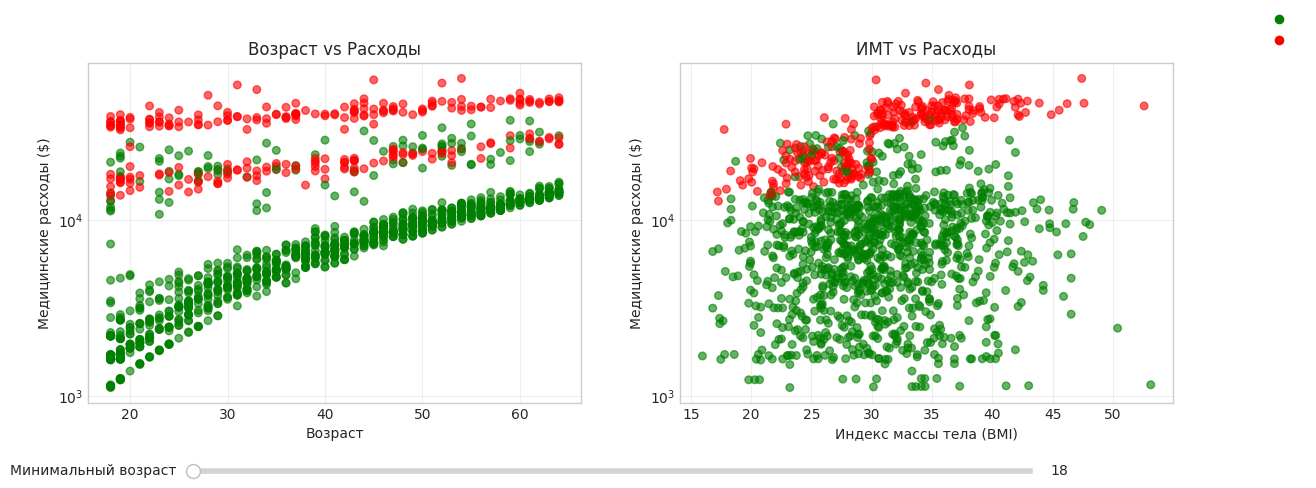

In [ ]:
# Создание фигуры с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plt.subplots_adjust(bottom=0.2)

# ========== ГРАФИК 1: Возраст и Расходы ==========
scatter1 = ax1.scatter(df['age'], df['charges'],
                       c=df['smoker'].map({'no': 'green', 'yes': 'red'}),
                       alpha=0.6, s=30)
ax1.set_xlabel('Возраст')
ax1.set_ylabel('Медицинские расходы ($)')
ax1.set_title('Возраст vs Расходы')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# ========== ГРАФИК 2: ИМТ и Расходы ==========
scatter2 = ax2.scatter(df['bmi'], df['charges'],
                       c=df['smoker'].map({'no': 'green', 'yes': 'red'}),
                       alpha=0.6, s=30)
ax2.set_xlabel('Индекс массы тела (BMI)')
ax2.set_ylabel('Медицинские расходы ($)')
ax2.set_title('ИМТ vs Расходы')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

# Общая легенда
fig.legend(['Некурящие', 'Курящие'], loc='upper right',
           handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8),
                    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8)])

# ========== СЛАЙДЕР ДЛЯ ФИЛЬТРАЦИИ ПО ВОЗРАСТУ ==========
ax_slider = plt.axes([0.2, 0.05, 0.6, 0.03])
slider = Slider(ax_slider, 'Минимальный возраст', 18, 64, valinit=18)

# Функция обновления
def update(val):
    min_age = slider.val
    filtered = df[df['age'] >= min_age]

    # Обновляем график 1
    scatter1.set_offsets(filtered[['age', 'charges']].values)
    scatter1.set_color(filtered['smoker'].map({'no': 'green', 'yes': 'red'}))

    # Обновляем график 2
    scatter2.set_offsets(filtered[['bmi', 'charges']].values)
    scatter2.set_color(filtered['smoker'].map({'no': 'green', 'yes': 'red'}))

    # Обновляем пределы осей
    ax1.relim()
    ax1.autoscale_view()
    ax2.relim()
    ax2.autoscale_view()

    fig.canvas.draw_idle()

slider.on_changed(update)
plt.show()

Данный код выполняет кодирование категориальных признаков (sex, smoker, region) в числовые значения с помощью метода map() и cat.codes для последующего корреляционного анализа. Первая тепловая карта визуализирует матрицу корреляции Пирсона между пятью числовыми признаками (age, bmi, children, smoker, charges), используя цветовую схему coolwarm где красный цвет указывает на положительную корреляцию, а синий — на отрицательную. Вторая тепловая карта отображает средние медицинские расходы в зависимости от региона проживания и статуса курения, что позволяет выявить региональные различия в страховых выплатах.


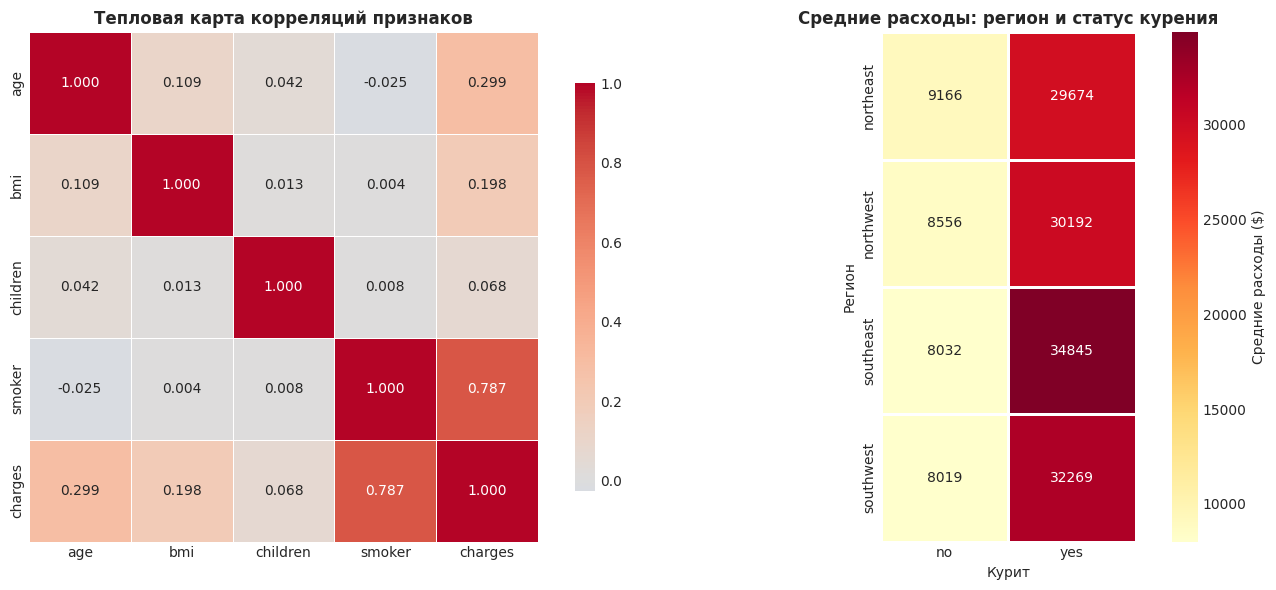

In [ ]:
# Кодирование категориальных признаков для корреляции
df_encoded = df.copy()
df_encoded['sex'] = df_encoded['sex'].map({'female': 0, 'male': 1})
df_encoded['smoker'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})
df_encoded['region'] = df_encoded['region'].astype('category').cat.codes

# Создание фигуры с двумя тепловыми картами
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ========== ТЕПЛОВАЯ КАРТА 1: Корреляция числовых признаков ==========
numeric_cols = ['age', 'bmi', 'children', 'smoker', 'charges']
corr_matrix = df_encoded[numeric_cols].corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.3f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            ax=ax1)
ax1.set_title('Тепловая карта корреляций признаков', fontsize=12, fontweight='bold')

# ========== ТЕПЛОВАЯ КАРТА 2: Средние расходы по региону и статусу курения ==========
pivot_table = df.pivot_table(values='charges',
                              index='region',
                              columns='smoker',
                              aggfunc='mean')

sns.heatmap(pivot_table, annot=True, fmt='.0f',cmap='YlOrRd',square=True,linewidths=1,cbar_kws={'label': 'Средние расходы ($)'},ax=ax2)
ax2.set_title('Средние расходы: регион и статус курения', fontsize=12, fontweight='bold')
ax2.set_xlabel('Курит')
ax2.set_ylabel('Регион')

plt.tight_layout()
plt.show()

Данный код загружает датасет insurance.csv и выполняет проверку на наличие полностью дублирующихся строк с использованием метода duplicated(). При обнаружении дубликатов код выводит их на экран и удаляет с помощью комбинации reset_index(drop=True).drop_duplicates(), что обеспечивает сброс индексов перед удалением для корректной обработки. Результат сохраняется в новую переменную df_clean, при этом в консоль выводится информация о количестве строк до и после очистки. При отсутствии дубликатов программа информирует пользователя, что дополнительная очистка не требуется.

In [ ]:

# Загрузка данных
df = pd.read_csv('insurance.csv')

print(f"До удаления: {len(df)}")
print(f"Дубликатов найдено: {df.duplicated().sum()}")

# Показываем дубликаты, если они есть
duplicates = df[df.duplicated(keep=False)]
if len(duplicates) > 0:
    print("\nНайдены дубликаты:")
    print(duplicates)

    df_clean = df.reset_index(drop=True).drop_duplicates()
    print(f"После reset_index + drop_duplicates(): {len(df_clean)}")
else:
    print("\nДубликатов нет в текущей версии DataFrame")
#df_clean.to_csv('insurance_clean.csv', index=False)

До удаления: 1337
Дубликатов найдено: 0

Дубликатов нет в текущей версии DataFrame


Данный код выполняет анализ и визуализацию выбросов для четырёх числовых признаков датасета: возраст, индекс массы тела (BMI), количество детей и медицинские расходы. Для каждого признака строится ящик с усами (boxplot), а также рассчитываются верхние и нижние границы на основе межквартильного размаха (IQR) по формуле Q1 - 1.5×IQR и Q3 + 1.5×IQR. Все значения, выходящие за эти границы, идентифицируются как выбросы, после чего в консоль выводится их количество, диапазон и статистическая информация. Результаты визуализируются в виде сетки графиков 2×2 с единым стилем оформления для наглядного сравнения распределений.

=== ВЫБРОСЫ ПО ВОЗРАСТУ ===
Границы: [-9, 87]
Количество выбросов: 0
Выбросы: нет

=== ВЫБРОСЫ ПО ИМТ ===
Границы: [13.7, 47.3]
Количество выбросов: 9
Диапазон выбросов: [47.4, 53.1]

=== ВЫБРОСЫ ПО КОЛИЧЕСТВУ ДЕТЕЙ ===
Границы: [-3.0, 5.0]
Количество выбросов: 0
Выбросы: нет

=== ВЫБРОСЫ ПО РАСХОДАМ ===
Границы: [$-13121, $34525]
Количество выбросов: 139
Диапазон выбросов: [$34618, $63770]
Максимальные расходы: $63770


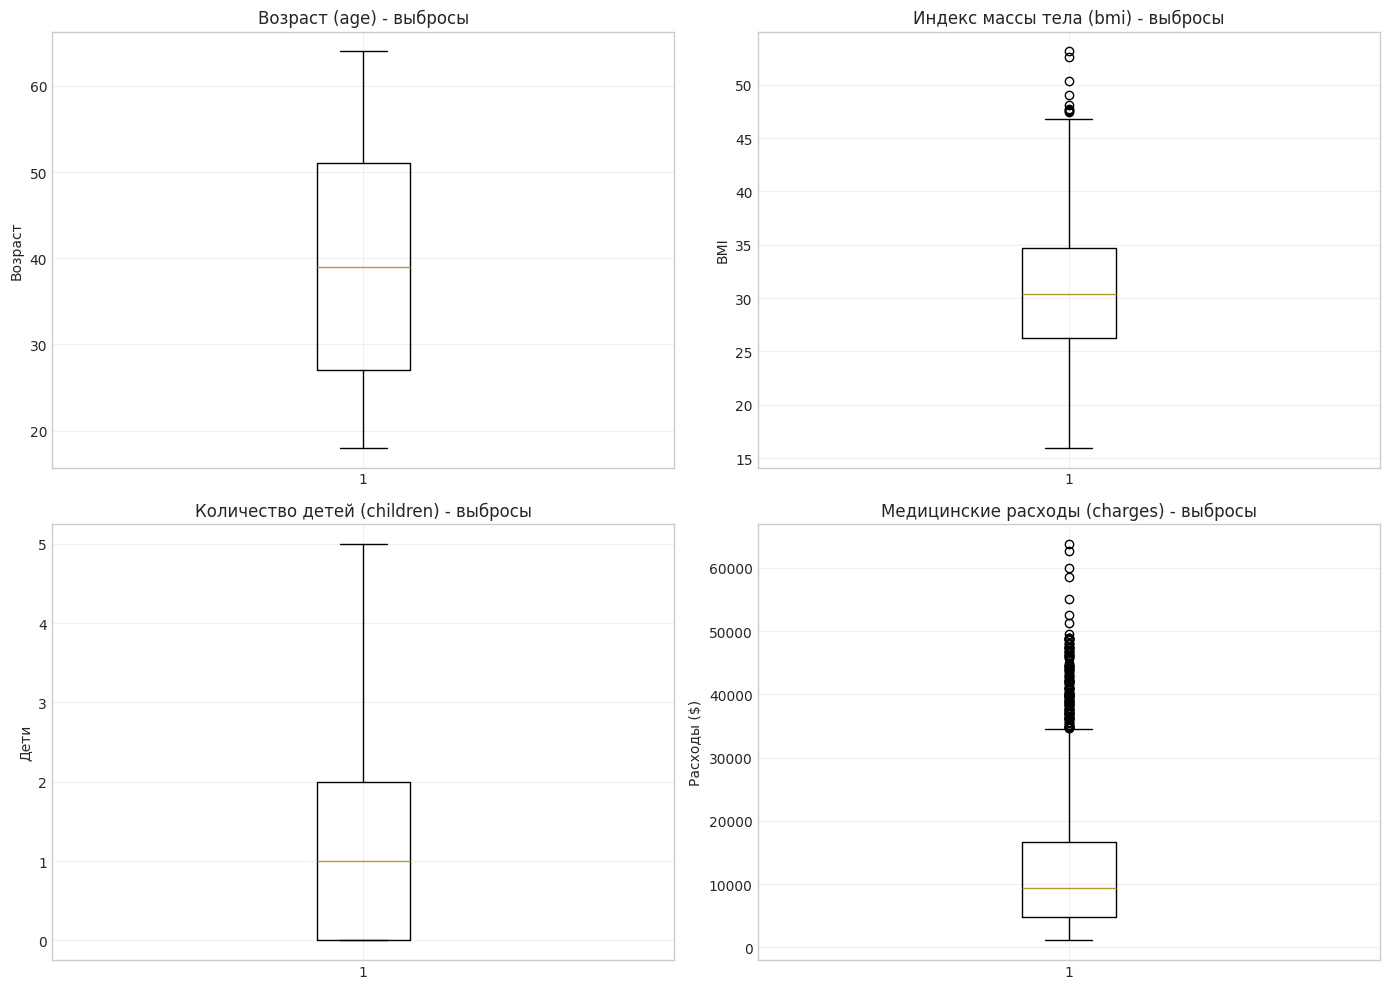

In [ ]:
# Создание фигуры
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ========== 1. ВЫБРОСЫ ПО ВОЗРАСТУ ==========
ax1 = axes[0, 0]
ax1.boxplot(df['age'])
ax1.set_title('Возраст (age) - выбросы')
ax1.set_ylabel('Возраст')
ax1.grid(True, alpha=0.3)

# Расчет границ для возраста
Q1_age = df['age'].quantile(0.25)
Q3_age = df['age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age
outliers_age = df[(df['age'] < lower_age) | (df['age'] > upper_age)]

print("=== ВЫБРОСЫ ПО ВОЗРАСТУ ===")
print(f"Границы: [{lower_age:.0f}, {upper_age:.0f}]")
print(f"Количество выбросов: {len(outliers_age)}")
print(f"Выбросы: {sorted(outliers_age['age'].unique()) if len(outliers_age) > 0 else 'нет'}\n")

# ========== 2. ВЫБРОСЫ ПО ИМТ ==========
ax2 = axes[0, 1]
ax2.boxplot(df['bmi'])
ax2.set_title('Индекс массы тела (bmi) - выбросы')
ax2.set_ylabel('BMI')
ax2.grid(True, alpha=0.3)

Q1_bmi = df['bmi'].quantile(0.25)
Q3_bmi = df['bmi'].quantile(0.75)
IQR_bmi = Q3_bmi - Q1_bmi
lower_bmi = Q1_bmi - 1.5 * IQR_bmi
upper_bmi = Q3_bmi + 1.5 * IQR_bmi
outliers_bmi = df[(df['bmi'] < lower_bmi) | (df['bmi'] > upper_bmi)]

print("=== ВЫБРОСЫ ПО ИМТ ===")
print(f"Границы: [{lower_bmi:.1f}, {upper_bmi:.1f}]")
print(f"Количество выбросов: {len(outliers_bmi)}")
print(f"Диапазон выбросов: [{outliers_bmi['bmi'].min():.1f}, {outliers_bmi['bmi'].max():.1f}]" if len(outliers_bmi) > 0 else "Выбросов нет\n")

# ========== 3. ВЫБРОСЫ ПО КОЛИЧЕСТВУ ДЕТЕЙ ==========
ax3 = axes[1, 0]
ax3.boxplot(df['children'])
ax3.set_title('Количество детей (children) - выбросы')
ax3.set_ylabel('Дети')
ax3.grid(True, alpha=0.3)

Q1_child = df['children'].quantile(0.25)
Q3_child = df['children'].quantile(0.75)
IQR_child = Q3_child - Q1_child
lower_child = Q1_child - 1.5 * IQR_child
upper_child = Q3_child + 1.5 * IQR_child
outliers_child = df[(df['children'] < lower_child) | (df['children'] > upper_child)]

print("\n=== ВЫБРОСЫ ПО КОЛИЧЕСТВУ ДЕТЕЙ ===")
print(f"Границы: [{lower_child:.1f}, {upper_child:.1f}]")
print(f"Количество выбросов: {len(outliers_child)}")
print(f"Выбросы: {sorted(outliers_child['children'].unique()) if len(outliers_child) > 0 else 'нет'}\n")

# ========== 4. ВЫБРОСЫ ПО РАСХОДАМ ==========
ax4 = axes[1, 1]
ax4.boxplot(df['charges'])
ax4.set_title('Медицинские расходы (charges) - выбросы')
ax4.set_ylabel('Расходы ($)')
ax4.grid(True, alpha=0.3)

Q1_charges = df['charges'].quantile(0.25)
Q3_charges = df['charges'].quantile(0.75)
IQR_charges = Q3_charges - Q1_charges
lower_charges = Q1_charges - 1.5 * IQR_charges
upper_charges = Q3_charges + 1.5 * IQR_charges
outliers_charges = df[(df['charges'] < lower_charges) | (df['charges'] > upper_charges)]

print("=== ВЫБРОСЫ ПО РАСХОДАМ ===")
print(f"Границы: [${lower_charges:.0f}, ${upper_charges:.0f}]")
print(f"Количество выбросов: {len(outliers_charges)}")
print(f"Диапазон выбросов: [${outliers_charges['charges'].min():.0f}, ${outliers_charges['charges'].max():.0f}]" if len(outliers_charges) > 0 else "Выбросов нет")
print(f"Максимальные расходы: ${df['charges'].max():.0f}")

plt.tight_layout()
plt.show()

Данный код демонстрирует три различных варианта фильтрации данных из датасета страховых расходов с использованием условий на один, два и три признака. Первая фильтрация выделяет курящих пациентов с годовыми расходами выше 40 000 долларов, позволяя проанализировать наиболее затратную группу клиентов. Вторая фильтрация находит молодых людей в возрасте 18–25 лет с ожирением (BMI > 30), что позволяет оценить распространённость факторов риска среди молодёжи. Третья фильтрация комбинирует три условия (пол, регион, количество детей и уровень расходов) для выявления многодетных женщин из юго-восточного региона с аномально низкими медицинскими расходами. Результаты каждой фильтрации выводятся в консоль с указанием количества найденных записей, ключевых статистических показателей и примеров отфильтрованных данных.



In [ ]:

print("=== ИСХОДНЫЕ ДАННЫЕ ===")
print(f"Всего записей: {len(df)}")
print(df.head(), "\n")

# ========== ФИЛЬТРАЦИЯ 1: По одному признаку ==========
print("=" * 60)
print("ФИЛЬТРАЦИЯ 1: Курящие люди с расходами выше 40000")
print("=" * 60)

filter1 = df[(df['smoker'] == 'yes') & (df['charges'] > 40000)]
print(f"Найдено записей: {len(filter1)}")
print(filter1[['age', 'sex', 'bmi', 'children', 'smoker', 'charges']].head(10))
print(f"\nСредние расходы: ${filter1['charges'].mean():,.0f}")
print(f"Диапазон возраста: {filter1['age'].min()} - {filter1['age'].max()} лет\n")

# ========== ФИЛЬТРАЦИЯ 2: По двум признакам (сложное условие) ==========
print("=" * 60)
print("ФИЛЬТРАЦИЯ 2: Молодые люди (18-25 лет) с ожирением (BMI > 30)")
print("=" * 60)

filter2 = df[(df['age'].between(18, 25)) & (df['bmi'] > 30)]
print(f"Найдено записей: {len(filter2)}")
print(filter2[['age', 'sex', 'bmi', 'children', 'smoker', 'charges']].head(10))
print(f"\nСредний ИМТ: {filter2['bmi'].mean():.1f}")
print(f"Доля курящих: {filter2['smoker'].value_counts(normalize=True).get('yes', 0)*100:.1f}%\n")

# ========== ФИЛЬТРАЦИЯ 3: По трем признакам с агрегацией ==========
print("=" * 60)
print("ФИЛЬТРАЦИЯ 3: Женщины из southeast с 3+ детьми и низкими расходами")
print("=" * 60)

filter3 = df[(df['sex'] == 'female') &
             (df['region'] == 'southeast') &
             (df['children'] >= 3) &
             (df['charges'] < 10000)]
print(f"Найдено записей: {len(filter3)}")
print(filter3[['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']])
print(f"\nСредний возраст: {filter3['age'].mean():.1f} лет")
print(f"Средний ИМТ: {filter3['bmi'].mean():.1f}")
print(f"Средние расходы: ${filter3['charges'].mean():,.0f}")

=== ИСХОДНЫЕ ДАННЫЕ ===
Всего записей: 1337
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520 

ФИЛЬТРАЦИЯ 1: Курящие люди с расходами выше 40000
Найдено записей: 79
     age     sex     bmi  children smoker      charges
34    28    male  36.400         1    yes  51194.55914
39    60    male  39.900         0    yes  48173.36100
55    58    male  36.955         2    yes  47496.49445
86    57  female  31.160         0    yes  43578.93940
94    64  female  31.300         2    yes  47291.05500
109   63    male  35.090         0    yes  47055.53210
146   46    male  30.495         3    yes  40720.55105
175   63  female  37.700         0    yes  48824.45000
185  

Данный код выполняет добавление искусственного шума в два признака датасета — bmi (индекс массы тела) и age (возраст). Для bmi используется гауссовский шум с нулевым средним и стандартным отклонением 2, для age — равномерный шум в диапазоне от -2 до +2 лет. После добавления шума значения ограничиваются реалистичными границами: bmi от 10 до 60, age от 18 до 64 лет. Код выводит статистику исходных и зашумленных признаков (среднее, стандартное отклонение, диапазон), визуализирует гистограммы распределений до и после добавления шума, а также показывает примеры изменений для первых 10 записей. Результат сохраняется в файл insurance_noisy.csv.

=== ДОБАВЛЕНИЕ ШУМА В ПРИЗНАКИ ===

Исходное количество записей: 1337

1. ДОБАВЛЕНИЕ ШУМА В ПРИЗНАК BMI
Статистика исходного BMI:
  Среднее: 30.66
  Стандартное отклонение: 6.10
  Диапазон: [15.96, 53.13]

Статистика BMI после добавления шума:
  Среднее: 30.74
  Стандартное отклонение: 6.41
  Диапазон: [14.13, 53.88]

2. ДОБАВЛЕНИЕ ШУМА В ПРИЗНАК AGE
Статистика исходного возраста:
  Среднее: 39.22
  Стандартное отклонение: 14.04
  Диапазон: [18, 64]

Статистика возраста после добавления шума:
  Среднее: 39.21
  Стандартное отклонение: 14.03
  Диапазон: [18.0, 64.0]


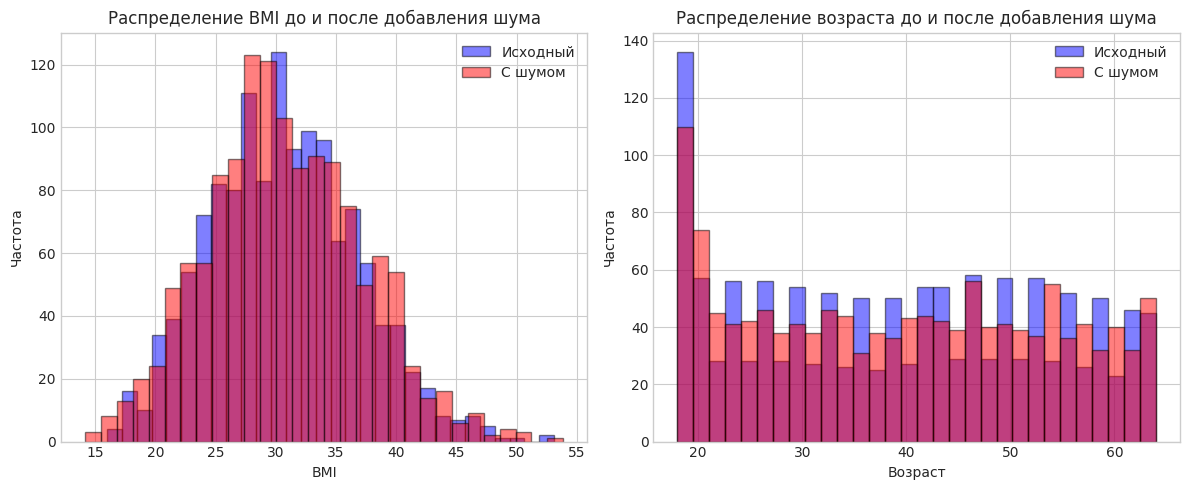


ПРИМЕРЫ ИЗМЕНЕНИЙ ЗНАЧЕНИЙ (первые 10 записей)
   BMI_исходный  BMI_с_шумом  BMI_изменение  Age_исходный  Age_с_шумом  \
0         27.90        28.89           0.99            19         19.8   
1         33.77        33.49          -0.28            18         18.0   
2         33.00        34.30           1.30            28         26.9   
3         22.70        25.75           3.05            33         33.2   
4         28.88        28.41          -0.47            32         32.9   
5         25.74        25.27          -0.47            31         30.7   
6         33.44        36.60           3.16            46         47.9   
7         27.74        29.27           1.53            37         37.7   
8         29.83        28.89          -0.94            37         36.9   
9         25.84        26.93           1.09            60         59.6   

   Age_изменение  
0            0.8  
1            0.0  
2           -1.1  
3            0.2  
4            0.9  
5           -0.3  
6   

In [ ]:
print("=== ДОБАВЛЕНИЕ ШУМА В ПРИЗНАКИ ===\n")
print(f"Исходное количество записей: {len(df)}")

# Копия данных для добавления шума
df_noisy = df.copy()

# ========== 1. ДОБАВЛЕНИЕ ШУМА В ПРИЗНАК BMI ==========
print("\n" + "="*60)
print("1. ДОБАВЛЕНИЕ ШУМА В ПРИЗНАК BMI")
print("="*60)

# Сохраняем исходные значения для сравнения
original_bmi = df_noisy['bmi'].copy()

# Добавляем гауссовский шум (нормальное распределение)
np.random.seed(42)
noise_bmi = np.random.normal(0, 2, size=len(df_noisy))  # среднее 0, std=2
df_noisy['bmi'] = df_noisy['bmi'] + noise_bmi

# Ограничиваем значения физически возможными (BMI не может быть <10 или >60)
df_noisy['bmi'] = df_noisy['bmi'].clip(10, 60)

print(f"Статистика исходного BMI:")
print(f"  Среднее: {original_bmi.mean():.2f}")
print(f"  Стандартное отклонение: {original_bmi.std():.2f}")
print(f"  Диапазон: [{original_bmi.min():.2f}, {original_bmi.max():.2f}]")

print(f"\nСтатистика BMI после добавления шума:")
print(f"  Среднее: {df_noisy['bmi'].mean():.2f}")
print(f"  Стандартное отклонение: {df_noisy['bmi'].std():.2f}")
print(f"  Диапазон: [{df_noisy['bmi'].min():.2f}, {df_noisy['bmi'].max():.2f}]")

# ========== 2. ДОБАВЛЕНИЕ ШУМА В ПРИЗНАК AGE ==========
print("\n" + "="*60)
print("2. ДОБАВЛЕНИЕ ШУМА В ПРИЗНАК AGE")
print("="*60)

# Сохраняем исходные значения
original_age = df_noisy['age'].copy()

# Добавляем равномерный шум
np.random.seed(123)
noise_age = np.random.uniform(-2, 2, size=len(df_noisy))  # от -2 до +2 лет
df_noisy['age'] = df_noisy['age'] + noise_age

# Ограничиваем возраст реалистичными границами (18-64 года)
df_noisy['age'] = df_noisy['age'].clip(18, 64).round(1)

print(f"Статистика исходного возраста:")
print(f"  Среднее: {original_age.mean():.2f}")
print(f"  Стандартное отклонение: {original_age.std():.2f}")
print(f"  Диапазон: [{original_age.min():.0f}, {original_age.max():.0f}]")

print(f"\nСтатистика возраста после добавления шума:")
print(f"  Среднее: {df_noisy['age'].mean():.2f}")
print(f"  Стандартное отклонение: {df_noisy['age'].std():.2f}")
print(f"  Диапазон: [{df_noisy['age'].min():.1f}, {df_noisy['age'].max():.1f}]")

# ========== ВИЗУАЛИЗАЦИЯ ВЛИЯНИЯ ШУМА ==========
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# График 1: BMI до и после шума
axes[0].hist(original_bmi, bins=30, alpha=0.5, label='Исходный', color='blue', edgecolor='black')
axes[0].hist(df_noisy['bmi'], bins=30, alpha=0.5, label='С шумом', color='red', edgecolor='black')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение BMI до и после добавления шума')
axes[0].legend()

# График 2: Age до и после шума
axes[1].hist(original_age, bins=30, alpha=0.5, label='Исходный', color='blue', edgecolor='black')
axes[1].hist(df_noisy['age'], bins=30, alpha=0.5, label='С шумом', color='red', edgecolor='black')
axes[1].set_xlabel('Возраст')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение возраста до и после добавления шума')
axes[1].legend()

plt.tight_layout()
plt.show()

# ========== ВЫВОД ПРИМЕРОВ ИЗМЕНЕНИЙ ==========
print("\n" + "="*60)
print("ПРИМЕРЫ ИЗМЕНЕНИЙ ЗНАЧЕНИЙ (первые 10 записей)")
print("="*60)

comparison = pd.DataFrame({
    'BMI_исходный': original_bmi[:10],
    'BMI_с_шумом': df_noisy['bmi'][:10],
    'BMI_изменение': df_noisy['bmi'][:10] - original_bmi[:10],
    'Age_исходный': original_age[:10],
    'Age_с_шумом': df_noisy['age'][:10],
    'Age_изменение': df_noisy['age'][:10] - original_age[:10]
})
print(comparison.round(2))
df_noisy.to_csv('insurance_noisy.csv', index=False)

Данный код загружает файл insurance_noisy.csv (данные после добавления шума) и выполняет анализ признака children на наличие редких значений. В результате анализа выявляется, что значения 4 и 5 встречаются редко (менее 2% каждое), поэтому принимается решение об их агрегации. Код создаёт новый категориальный признак children_cat, в котором значения 4 и 5 объединяются в группу «4+», а остальные значения (0, 1, 2, 3) сохраняются в исходном виде. После преобразования выводится обновлённое распределение по количеству детей, а результат сохраняется в файл insurance_noisy_3.csv.

In [ ]:
print("=== АНАЛИЗ РЕДКИХ ДАННЫХ ===\n")
df_new = pd.read_csv('insurance_noisy.csv')

# ========== 1. АНАЛИЗ ПРИЗНАКА CHILDREN (редкие данные) ==========
print("1. Признак children (количество детей):")
children_counts = df_new['children'].value_counts().sort_index()
for val, count in children_counts.items():
    print(f"   {val}: {count} ({count/len(df_new)*100:.1f}%)")

print("\n   Вывод: значения 4 и 5 являются редкими (<2%), будут объединены в группу '4+'")

# ========== 2. ПРЕОБРАЗОВАНИЕ CHILDREN (редкие данные в группу) ==========
df_new['children_cat'] = df_new['children'].apply(lambda x: '4+' if x >= 4 else str(x))
print("\nРаспределение по количеству детей (с учётом агрегации):")
print(df_new['children_cat'].value_counts().sort_index())

df_new.to_csv('insurance_noisy_3.csv', index=False)

=== АНАЛИЗ РЕДКИХ ДАННЫХ ===

1. Признак children (количество детей):
   0: 573 (42.9%)
   1: 324 (24.2%)
   2: 240 (18.0%)
   3: 157 (11.7%)
   4: 25 (1.9%)
   5: 18 (1.3%)

   Вывод: значения 4 и 5 являются редкими (<2%), будут объединены в группу '4+'

Распределение по количеству детей (с учётом агрегации):
children_cat
0     573
1     324
2     240
3     157
4+     43
Name: count, dtype: int64


Данный код загружает исходные данные (df) и преобразованные данные из файла insurance_noisy_3.csv (содержащего добавленный шум в признаки age и bmi, а также агрегированную категорию children_cat). Для визуального сравнения строятся гистограммы распределений возраста, BMI и расходов, а также точечные графики зависимостей расходов от возраста и BMI с логарифмической шкалой и boxplot для BMI. После визуализации выводятся статистические показатели (среднее и стандартное отклонение) для каждого признака до и после трансформаций. Целевой признак charges остаётся неизменным, что подтверждается выводом его среднего значения.



/tmp/ipykernel_24931/4257233657.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 2].boxplot(bp_data, labels=['До', 'После'])


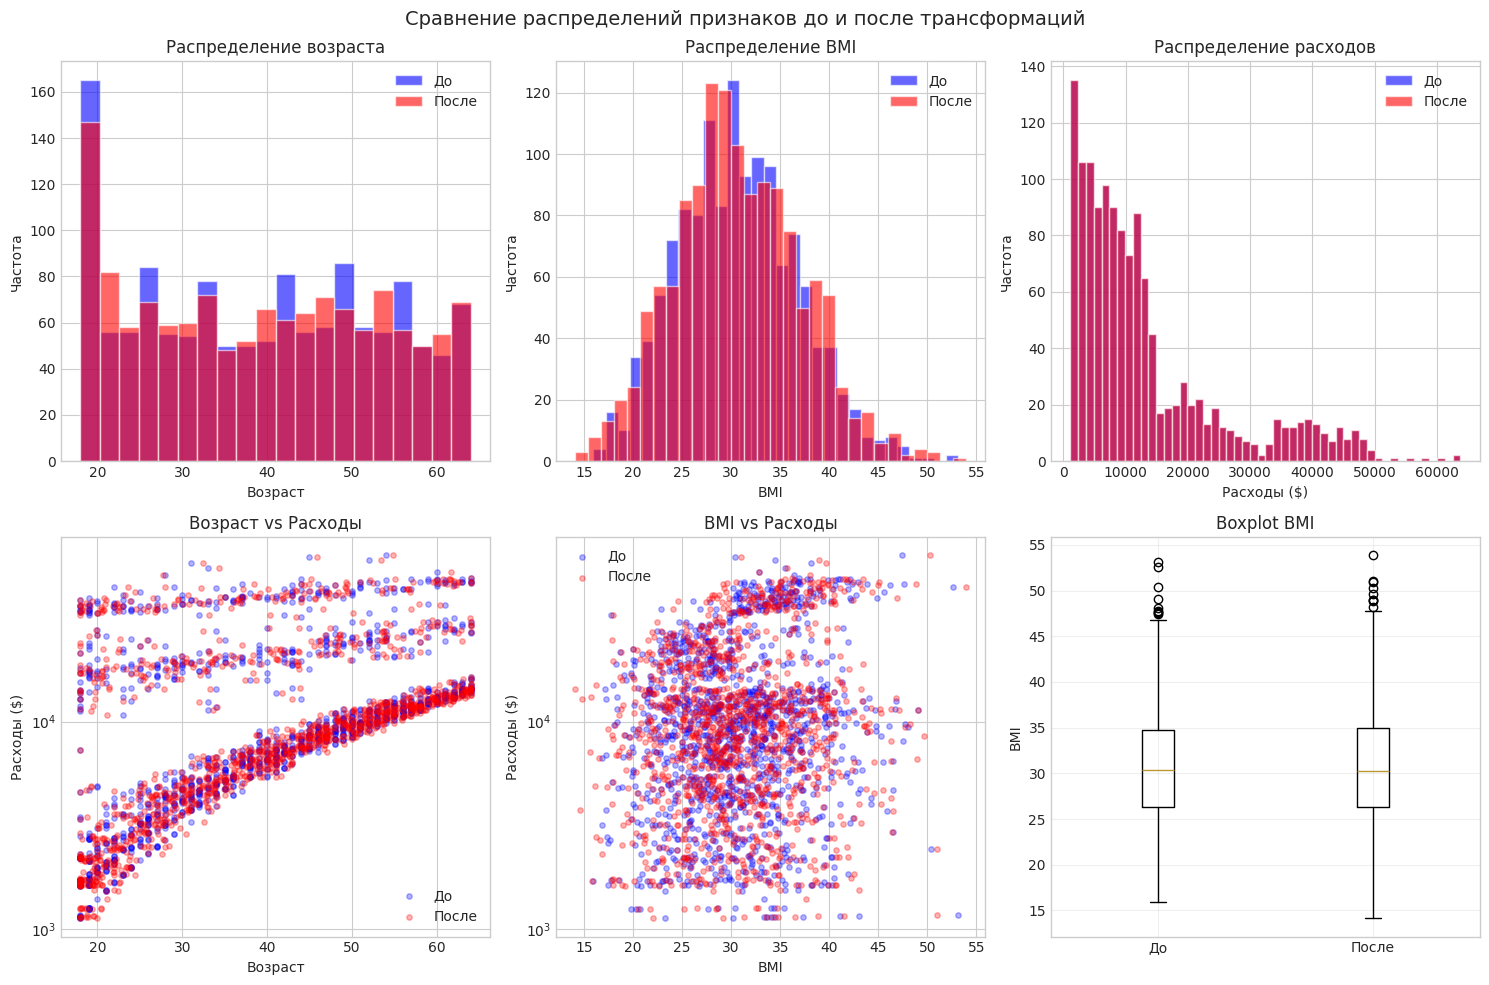


СТАТИСТИЧЕСКОЕ СРАВНЕНИЕ

Возраст:
  Среднее: 39.22 → 39.21
  Ст.откл.: 14.04 → 14.03

BMI:
  Среднее: 30.66 → 30.74
  Ст.откл.: 6.10 → 6.41

Расходы:
  Среднее: $13279 → $13279


In [ ]:

# ========== ПРИМЕНЕНИЕ ВСЕХ ТРАНСФОРМАЦИЙ ==========
df_transformed = pd.read_csv('insurance_noisy_3.csv')
df_original = df.copy()


# ========== ВИЗУАЛИЗАЦИЯ ==========
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Сравнение распределений признаков до и после трансформаций', fontsize=14)

# 1. Возраст
axes[0, 0].hist(df_original['age'], bins=20, alpha=0.6, label='До', color='blue')
axes[0, 0].hist(df_transformed['age'], bins=20, alpha=0.6, label='После', color='red')
axes[0, 0].set_xlabel('Возраст')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].set_title('Распределение возраста')
axes[0, 0].legend()

# 2. BMI
axes[0, 1].hist(df_original['bmi'], bins=30, alpha=0.6, label='До', color='blue')
axes[0, 1].hist(df_transformed['bmi'], bins=30, alpha=0.6, label='После', color='red')
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].set_title('Распределение BMI')
axes[0, 1].legend()

# 3. Расходы (без изменений)
axes[0, 2].hist(df_original['charges'], bins=50, alpha=0.6, label='До', color='blue')
axes[0, 2].hist(df_transformed['charges'], bins=50, alpha=0.6, label='После', color='red')
axes[0, 2].set_xlabel('Расходы ($)')
axes[0, 2].set_ylabel('Частота')
axes[0, 2].set_title('Распределение расходов')
axes[0, 2].legend()

# 4. Age vs Charges
axes[1, 0].scatter(df_original['age'], df_original['charges'], alpha=0.3, s=15, label='До', color='blue')
axes[1, 0].scatter(df_transformed['age'], df_transformed['charges'], alpha=0.3, s=15, label='После', color='red')
axes[1, 0].set_xlabel('Возраст')
axes[1, 0].set_ylabel('Расходы ($)')
axes[1, 0].set_title('Возраст vs Расходы')
axes[1, 0].set_yscale('log')
axes[1, 0].legend()

# 5. BMI vs Charges
axes[1, 1].scatter(df_original['bmi'], df_original['charges'], alpha=0.3, s=15, label='До', color='blue')
axes[1, 1].scatter(df_transformed['bmi'], df_transformed['charges'], alpha=0.3, s=15, label='После', color='red')
axes[1, 1].set_xlabel('BMI')
axes[1, 1].set_ylabel('Расходы ($)')
axes[1, 1].set_title('BMI vs Расходы')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()

# 6. Boxplot BMI
bp_data = [df_original['bmi'], df_transformed['bmi']]
axes[1, 2].boxplot(bp_data, labels=['До', 'После'])
axes[1, 2].set_title('Boxplot BMI')
axes[1, 2].set_ylabel('BMI')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========== СТАТИСТИКА ==========
print("\n" + "="*50)
print("СТАТИСТИЧЕСКОЕ СРАВНЕНИЕ")
print("="*50)

print("\nВозраст:")
print(f"  Среднее: {df_original['age'].mean():.2f} → {df_transformed['age'].mean():.2f}")
print(f"  Ст.откл.: {df_original['age'].std():.2f} → {df_transformed['age'].std():.2f}")

print("\nBMI:")
print(f"  Среднее: {df_original['bmi'].mean():.2f} → {df_transformed['bmi'].mean():.2f}")
print(f"  Ст.откл.: {df_original['bmi'].std():.2f} → {df_transformed['bmi'].std():.2f}")

print("\nРасходы:")
print(f"  Среднее: ${df_original['charges'].mean():.0f} → ${df_transformed['charges'].mean():.0f}")

Данный код выводит полную информацию о категориальных признаках датасета: поле, статус курения и регион. Для каждого признака отображаются уникальные категории, их общее количество, а также абсолютная и относительная частота встречаемости каждой категории в процентах.

In [ ]:
print("=== КАТЕГОРИИ ПО ПРИЗНАКАМ ===\n")

# 1. Пол (sex)
print("1. Пол (sex):")
print(f"   Категории: {', '.join(df['sex'].unique())}")
print(f"   Количество: {df['sex'].nunique()}\n")
for sex, count in sex_counts.items():
    print(f"   {sex}: {count} ({count/len(df)*100:.1f}%)")

# 2. Статус курения (smoker)
print("2. Статус курения (smoker):")
print(f"   Категории: {', '.join(df['smoker'].unique())}")
print(f"   Количество: {df['smoker'].nunique()}\n")
for status, count in smoker_counts.items():
    print(f"   {status}: {count} ({count/len(df)*100:.1f}%)")

# 3. Регион (region)
print("3. Регион (region):")
print(f"   Категории: {', '.join(df['region'].unique())}")
print(f"   Количество: {df['region'].nunique()}\n")
for region, count in region_counts.items():
    print(f"   {region}: {count} ({count/len(df)*100:.1f}%)")




=== КАТЕГОРИИ ПО ПРИЗНАКАМ ===

1. Пол (sex):
   Категории: female, male
   Количество: 2

   male: 676 (50.6%)
   female: 662 (49.5%)
2. Статус курения (smoker):
   Категории: yes, no
   Количество: 2

   no: 1064 (79.6%)
   yes: 274 (20.5%)
3. Регион (region):
   Категории: southwest, southeast, northwest, northeast
   Количество: 4

   southeast: 364 (27.2%)
   southwest: 325 (24.3%)
   northwest: 325 (24.3%)
   northeast: 324 (24.2%)


Данный код создаёт три столбчатые диаграммы для визуализации распределения категориальных признаков датасета: пола (sex), статуса курения (smoker) и региона проживания (region). Каждая диаграмма отображает частоту встречаемости каждой категории.



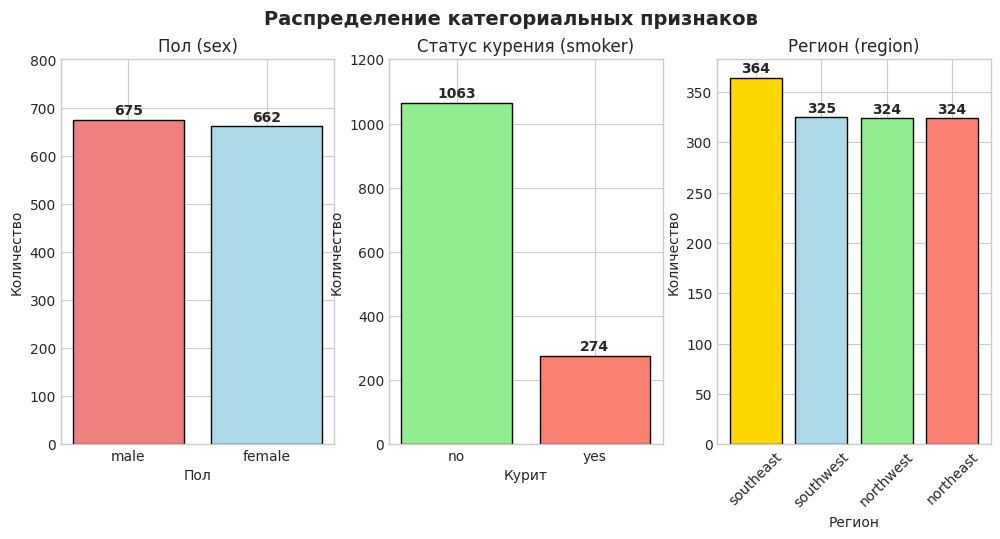

In [ ]:
# Создание фигуры
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle('Распределение категориальных признаков', fontsize=14, fontweight='bold')

# ========== 1. РАСПРЕДЕЛЕНИЕ ПО ПОЛУ (sex) ==========
sex_counts = df['sex'].value_counts()
colors_sex = ['lightcoral', 'lightblue']
axes[0].bar(sex_counts.index, sex_counts.values, color=colors_sex, edgecolor='black')
axes[0].set_title('Пол (sex)', fontsize=12)
axes[0].set_xlabel('Пол')
axes[0].set_ylabel('Количество')
axes[0].set_ylim(0, 800)

# Добавление значений на столбцы
for i, v in enumerate(sex_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# ========== 2. РАСПРЕДЕЛЕНИЕ ПО СТАТУСУ КУРЕНИЯ (smoker) ==========
smoker_counts = df['smoker'].value_counts()
colors_smoker = ['lightgreen', 'salmon']
axes[1].bar(smoker_counts.index, smoker_counts.values, color=colors_smoker, edgecolor='black')
axes[1].set_title('Статус курения (smoker)', fontsize=12)
axes[1].set_xlabel('Курит')
axes[1].set_ylabel('Количество')
axes[1].set_ylim(0, 1200)

for i, v in enumerate(smoker_counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

# ========== 3. РАСПРЕДЕЛЕНИЕ ПО РЕГИОНУ (region) ==========
region_counts = df['region'].value_counts()
colors_region = ['gold', 'lightblue', 'lightgreen', 'salmon']
axes[2].bar(region_counts.index, region_counts.values, color=colors_region, edgecolor='black')
axes[2].set_title('Регион (region)', fontsize=12)
axes[2].set_xlabel('Регион')
axes[2].set_ylabel('Количество')
axes[2].tick_params(axis='x', rotation=45)

for i, v in enumerate(region_counts.values):
    axes[2].text(i, v + 5, str(v), ha='center', fontweight='bold')




Данный код выполняет преобразование категориальных признаков sex, smoker и region в числовые значения с использованием метода Label Encoding. Для каждого признака создаётся словарь соответствий: пол кодируется как 0 (female) и 1 (male), статус курения — как 0 (no) и 1 (yes), а регионы получают последовательные числовые идентификаторы от 0 до 3 в алфавитном порядке. Результат преобразования сохраняется в новые столбцы с суффиксом _label и выводится в виде итоговой таблицы для визуального контроля корректности кодирования.

In [ ]:
print("=== ИСХОДНЫЕ ДАННЫЕ ===")
print(df[['sex', 'smoker', 'region']].head(10))
print(f"\nВсего записей: {len(df)}")

# ========== 1. LABEL ENCODING ==========
print("\n" + "="*60)
print("1. LABEL ENCODING (присвоение числовых идентификаторов)")
print("="*60)

df_label = df.copy()

# Преобразование пола
sex_mapping = {'female': 0, 'male': 1}
df_label['sex_label'] = df_label['sex'].map(sex_mapping)

# Преобразование статуса курения
smoker_mapping = {'no': 0, 'yes': 1}
df_label['smoker_label'] = df_label['smoker'].map(smoker_mapping)

# Преобразование региона
region_mapping = {region: i for i, region in enumerate(sorted(df['region'].unique()))}
df_label['region_label'] = df_label['region'].map(region_mapping)

print("Соответствия:")
print(f"  sex: {sex_mapping}")
print(f"  smoker: {smoker_mapping}")
print(f"  region: {region_mapping}")

# ========== ИТОГОВАЯ ТАБЛИЦА ==========
print("\n" + "="*60)
print("ИТОГОВАЯ ТАБЛИЦА СО ВСЕМИ ПРЕОБРАЗОВАНИЯМИ")
print("="*60)

df_final = df.copy()
df_final['sex_label'] = df_final['sex'].map({'female': 0, 'male': 1})
df_final['smoker_label'] = df_final['smoker'].map({'no': 0, 'yes': 1})
df_final['region_label'] = df_final['region'].map({region: i for i, region in enumerate(sorted(df['region'].unique()))})




print(df_final.head(10))

=== ИСХОДНЫЕ ДАННЫЕ ===
      sex smoker     region
0  female    yes  southwest
1    male     no  southeast
2    male     no  southeast
3    male     no  northwest
4    male     no  northwest
5  female     no  southeast
6  female     no  southeast
7  female     no  northwest
8    male     no  northeast
9  female     no  northwest

Всего записей: 1337

1. LABEL ENCODING (присвоение числовых идентификаторов)
Соответствия:
  sex: {'female': 0, 'male': 1}
  smoker: {'no': 0, 'yes': 1}
  region: {'northeast': 0, 'northwest': 1, 'southeast': 2, 'southwest': 3}

ИТОГОВАЯ ТАБЛИЦА СО ВСЕМИ ПРЕОБРАЗОВАНИЯМИ
   age     sex     bmi  children smoker     region      charges  sex_label  \
0   19  female  27.900         0    yes  southwest  16884.92400          0   
1   18    male  33.770         1     no  southeast   1725.55230          1   
2   28    male  33.000         3     no  southeast   4449.46200          1   
3   33    male  22.705         0     no  northwest  21984.47061          1   
4   3

Данный код создаёт новую бинарную категорию risk_group (группа риска) на основе комбинации трёх признаков: возраста, индекса массы тела и статуса курения. Категория Высокий риск присваивается пациентам старше 50 лет или курящим с ИМТ выше 30, а Средний риск — всем остальным. После создания категории код выводит статистику распределения по группам и визуализирует результаты на двух диаграммах: столбчатой диаграмме количества пациентов в каждой группе и диаграмме средних медицинских расходов. В конце выводятся примеры записей для наглядной демонстрации работы новой категории.

=== ВВЕДЕНИЕ НОВОЙ КАТЕГОРИИ ===

НОВАЯ КАТЕГОРИЯ: ГРУППА РИСКА ПО ЗДОРОВЬЮ

Распределение по группам риска:
   Средний риск: 875 (65.4%)
   Высокий риск: 462 (34.6%)


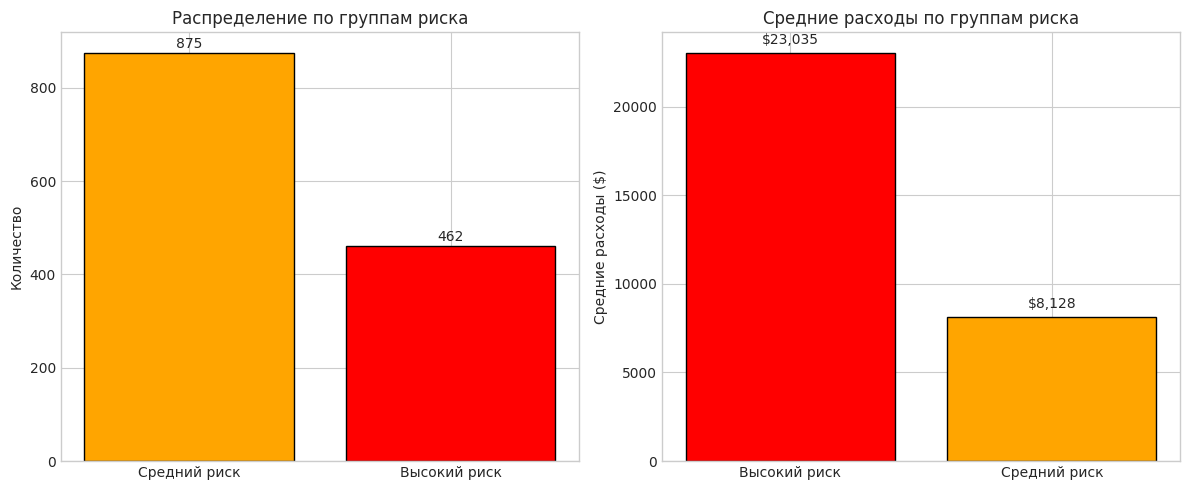


Примеры записей:
   age     bmi smoker      charges    risk_group
0   19  27.900    yes  16884.92400  Средний риск
1   18  33.770     no   1725.55230  Средний риск
2   28  33.000     no   4449.46200  Средний риск
3   33  22.705     no  21984.47061  Средний риск
4   32  28.880     no   3866.85520  Средний риск
5   31  25.740     no   3756.62160  Средний риск
6   46  33.440     no   8240.58960  Средний риск
7   37  27.740     no   7281.50560  Средний риск
8   37  29.830     no   6406.41070  Средний риск
9   60  25.840     no  28923.13692  Высокий риск


In [ ]:
print("=== ВВЕДЕНИЕ НОВОЙ КАТЕГОРИИ ===\n")

# ========== СОЗДАНИЕ НОВОЙ КАТЕГОРИИ "ГРУППА РИСКА" ==========
print("НОВАЯ КАТЕГОРИЯ: ГРУППА РИСКА ПО ЗДОРОВЬЮ")
print("="*60)

"""
Логика:
- Высокий риск: возраст > 50 ИЛИ (курит И BMI > 30)
- Средний риск: все остальные
"""

def risk_group(row):
    age = row['age']
    bmi = row['bmi']
    smoker = row['smoker']

    if age > 50 or (smoker == 'yes' and bmi > 30):
        return 'Высокий риск'
    else:
        return 'Средний риск'

df['risk_group'] = df.apply(risk_group, axis=1)

# Вывод статистики
risk_counts = df['risk_group'].value_counts()
print("\nРаспределение по группам риска:")
for group, count in risk_counts.items():
    print(f"   {group}: {count} ({count/len(df)*100:.1f}%)")


# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# График 1: Количество
colors = ['orange', 'red']
ax1.bar(risk_counts.index, risk_counts.values, color=colors, edgecolor='black')
ax1.set_title('Распределение по группам риска')
ax1.set_ylabel('Количество')
for i, v in enumerate(risk_counts.values):
    ax1.text(i, v + 10, str(v), ha='center')

# График 2: Средние расходы
risk_means = df.groupby('risk_group')['charges'].mean()
ax2.bar(risk_means.index, risk_means.values, color=['red','orange'], edgecolor='black')
ax2.set_title('Средние расходы по группам риска')
ax2.set_ylabel('Средние расходы ($)')
for i, v in enumerate(risk_means.values):
    ax2.text(i, v + 500, f'${v:,.0f}', ha='center')

plt.tight_layout()
plt.show()

# Примеры
print("\nПримеры записей:")
print(df[['age', 'bmi', 'smoker', 'charges', 'risk_group']].head(10))

Данный код создаёт категориальную переменную bmi_cat, разделяющую индекс массы тела на три группы: «Нормальный вес» (BMI < 25), «Избыточный вес» (BMI 25–30) и «Ожирение» (BMI > 30). Затем код группирует данные по категориям ИМТ и статусу курения, вычисляя средние медицинские расходы в каждой группе. Результат выводится в виде таблицы, где наглядно видно, что курящие пациенты с ожирением имеют наибольшие расходы. В конце код сравнивает две крайние группы: пациенты с ожирением и курением против пациентов с нормальным весом и отсутствием курения, выводя разницу в средних расходах.

In [ ]:
# Создаём категорию ИМТ
def bmi_category(bmi):
    if bmi < 25:
        return 'Нормальный вес'
    elif bmi < 30:
        return 'Избыточный вес'
    else:
        return 'Ожирение'

df['bmi_cat'] = df['bmi'].apply(bmi_category)

# Группируем по ИМТ и статусу курения
result = df.groupby(['bmi_cat', 'smoker'])['charges'].mean().unstack()

print("Средние расходы по группам:")
print(result.round(0))
print()

# Сравниваем ожирение + курение с другими группами
obese_smoker = result.loc['Ожирение', 'yes']
normal_non = result.loc['Нормальный вес', 'no']

print(f"Ожирение + курение: ${obese_smoker:,.0f}")
print(f"Нормальный вес + не курит: ${normal_non:,.0f}")
print(f"Разница: ${obese_smoker - normal_non:,.0f}")

Средние расходы по группам:
smoker              no      yes
bmi_cat                        
Избыточный вес  8258.0  22496.0
Нормальный вес  7516.0  19839.0
Ожирение        8856.0  41558.0

Ожирение + курение: $41,558
Нормальный вес + не курит: $7,516
Разница: $34,042
